In [2]:
import os
os.environ["HF_TOKEN"] = "YOUR_TOKEN_HERE"


So due to stogarge constraints we are streaming the dataset directly from source

In [ ]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("angeluriot/chess_games", split="train", streaming=True)

rows = list(dataset.take(10000))
df = pd.DataFrame(rows)

print(f"Loaded {len(df)} games")
df.head()

Loaded 10000 games


,date,white_elo,black_elo,end_type,winner,moves_san,moves_uci,moves_custom,source
0,2019.06.07,2481.0,2020.0,resignation,white,"[Nf3, c5, g3, Nc6, Bg2, g6, d4, cxd4, Nxd4, Bg...","[g1f3, c7c5, g2g3, b8c6, f1g2, g7g6, d2d4, c5d...","[w.♘g1♘f3.., b.♟c7♟c5.., w.♙g2♙g3.., b.♞b8♞c6....",TWIC
1,1991.??.??,NaN,2330.0,draw_agreement,NaN,"[e4, c5, Nf3, Nc6, d4, cxd4, Nxd4, g6, Nc3, Bg...","[e2e4, c7c5, g1f3, b8c6, d2d4, c5d4, f3d4, g7g...","[w.♙e2♙e4.., b.♟c7♟c5.., w.♘g1♘f3.., b.♞b8♞c6....",PGNMentor
2,2021.01.09,2738.0,2750.0,draw_agreement,NaN,"[Na3, e5, c3, Bxa3, bxa3, Nf6, g3, d5, Bg2, O-...","[b1a3, e7e5, c2c3, f8a3, b2a3, g8f6, g2g3, d7d...","[w.♘b1♘a3.., b.♟e7♟e5.., w.♙c2♙c3.., b.♝f8♝a3....",LichessEliteDatabase
3,2023.11.30,2935.0,2803.0,draw_agreement,NaN,"[e4, c5, Nc3, Nc6, Nf3, d6, d4, cxd4, Nxd4, Nf...","[e2e4, c7c5, b1c3, b8c6, g1f3, d7d6, d2d4, c5d...","[w.♙e2♙e4.., b.♟c7♟c5.., w.♘b1♘c3.., b.♞b8♞c6....",LichessEliteDatabase
4,2021.07.07,2572.0,2577.0,resignation,white,"[e4, d6, d4, g6, Nc3, Bg7, f4, a6, e5, b5, Qf3...","[e2e4, d7d6, d2d4, g7g6, b1c3, f8g7, f2f4, a7a...","[w.♙e2♙e4.., b.♟d7♟d6.., w.♙d2♙d4.., b.♟g7♟g6....",LichessEliteDatabase


In [4]:
df.isnull().sum().sum()

np.int64(4643)

In [5]:
df.isnull().sum()

date               0
white_elo       1156
black_elo       1167
end_type           0
winner          2320
moves_san          0
moves_uci          0
moves_custom       0
source             0
dtype: int64

Fixing winner as null are draw, also filling median for missing elos and also adding a flag 

In [6]:
df['winner'] = df['winner'].fillna('draw')

df['elo_missing'] = df['white_elo'].isnull()
df['white_elo'] = df['white_elo'].fillna(df['white_elo'].median())
df['black_elo'] = df['black_elo'].fillna(df['black_elo'].median())

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.describe()

,white_elo,black_elo
count,10000.000000,10000.000000
mean,2389.721500,2388.213300
std,278.686989,280.309463
min,619.000000,865.000000
25%,2226.750000,2221.000000
50%,2433.000000,2438.000000
75%,2593.000000,2591.000000
max,3078.000000,3071.000000


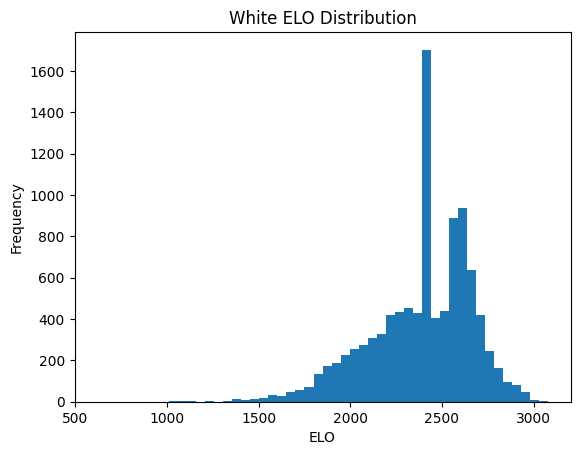

In [9]:
import matplotlib.pyplot as plt

plt.hist(df['white_elo'], bins=50)
plt.title('White ELO Distribution')
plt.xlabel('ELO')
plt.ylabel('Frequency')
plt.show()

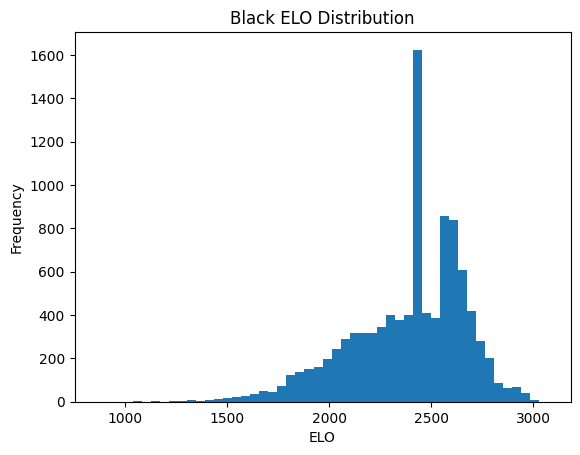

In [10]:
plt.hist(df['black_elo'], bins=50)
plt.title('Black ELO Distribution')
plt.xlabel('ELO')
plt.ylabel('Frequency')
plt.show()

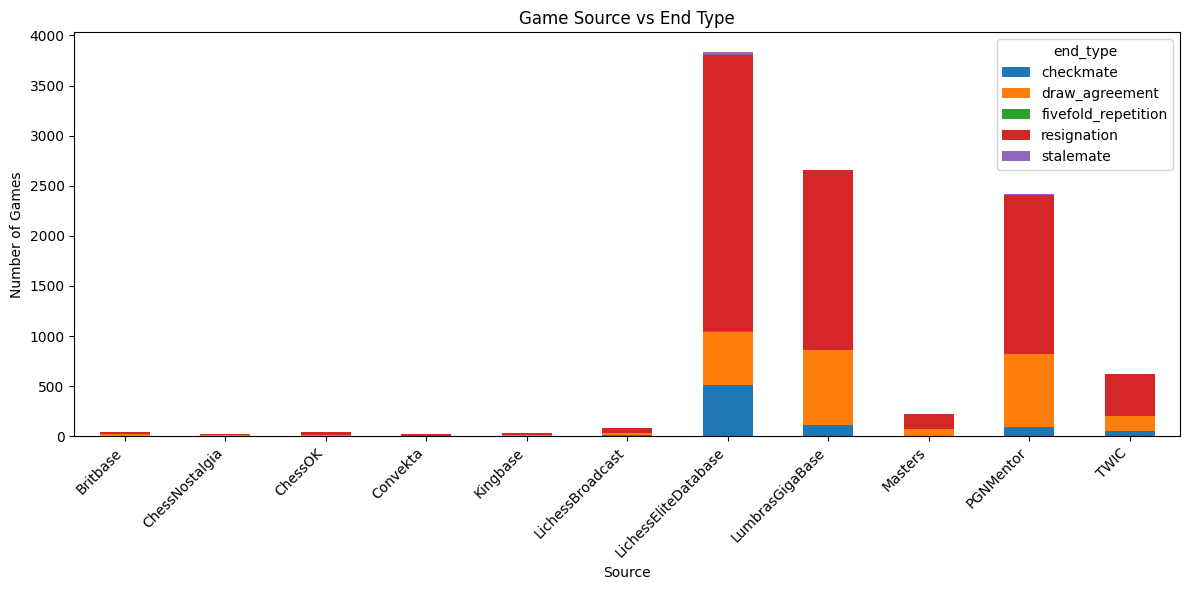

In [11]:
chart_df = pd.crosstab(df["source"], df["end_type"])

ax = chart_df.plot(kind="bar", stacked=True, figsize=(12, 6))
ax.set_title("Game Source vs End Type")
ax.set_xlabel("Source")
ax.set_ylabel("Number of Games")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

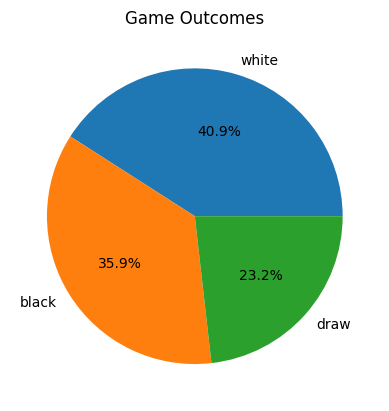

In [12]:
plt.pie(df['winner'].value_counts(), labels=df['winner'].value_counts().index, autopct='%1.1f%%')
plt.title('Game Outcomes')
plt.show()

In [15]:
import chess

moves = df.iloc[0]['moves_san']

board = chess.Board()

print("Playing the first 5 moves...")
for i in range(5):
    board.push_san(moves[i])

print("\nBoard State after 5 moves:")
print(board)

Playing the first 5 moves...

Board State after 5 moves:
r . b q k b n r
p p . p p p p p
. . n . . . . .
. . p . . . . .
. . . . . . . .
. . . . . N P .
P P P P P P B P
R N B Q K . . R


In [18]:
import numpy as np

piece_to_index = {
    'P': 0, 'N': 1, 'B': 2, 'R': 3, 'Q': 4, 'K': 5,  
    'p': 6, 'n': 7, 'b': 8, 'r': 9, 'q': 10, 'k': 11 
}

def board_to_tensor(board):
    tensor = np.zeros((12, 8, 8), dtype=np.float32)
    
    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece:
            channel = piece_to_index[piece.symbol()]
            
            row = chess.square_rank(square)
            col = chess.square_file(square)
            
            tensor[channel][row][col] = 1.0
            
    return tensor

matrix = board_to_tensor(board)

print(f"Tensor Shape: {matrix.shape}")
print("\nHere is the 'White Knights' channel (Channel 1):")
print(matrix[1]) 

Tensor Shape: (12, 8, 8)

Here is the 'White Knights' channel (Channel 1):
[[0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


In [19]:
print(board.turn)

False


In [20]:
print(board.has_castling_rights(chess.WHITE))

True


In [21]:
print(board.has_legal_en_passant())

False


In [22]:
legal_moves = list(board.legal_moves)
print(f"There are {len(legal_moves)} legal moves right now.")
print(f"List of legal moves: {legal_moves}")

import random
random_move = random.choice(legal_moves)
print(f"\nMaking random move: {random_move}")
board.push(random_move)

print(board)

There are 26 legal moves right now.
List of legal moves: [Move.from_uci('g8h6'), Move.from_uci('g8f6'), Move.from_uci('d8c7'), Move.from_uci('d8b6'), Move.from_uci('d8a5'), Move.from_uci('a8b8'), Move.from_uci('c6b8'), Move.from_uci('c6e5'), Move.from_uci('c6a5'), Move.from_uci('c6d4'), Move.from_uci('c6b4'), Move.from_uci('h7h6'), Move.from_uci('g7g6'), Move.from_uci('f7f6'), Move.from_uci('e7e6'), Move.from_uci('d7d6'), Move.from_uci('b7b6'), Move.from_uci('a7a6'), Move.from_uci('c5c4'), Move.from_uci('h7h5'), Move.from_uci('g7g5'), Move.from_uci('f7f5'), Move.from_uci('e7e5'), Move.from_uci('d7d5'), Move.from_uci('b7b5'), Move.from_uci('a7a5')]

Making random move: h7h5
r . b q k b n r
p p . p p p p .
. . n . . . . .
. . p . . . . p
. . . . . . . .
. . . . . N P .
P P P P P P B P
R N B Q K . . R
